<a href="https://colab.research.google.com/github/vikash000x/AutoEnocoder_VAE/blob/main/AutoEncoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import libraries

In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

define device

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data into train and val

In [48]:
batch_size = 128
data_transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(root="./data", train= True, transform = data_transform, download= True)
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.0MB/s]


In [49]:
test_dataset = datasets.MNIST(root="./data", train= False, transform = data_transform, download= True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

### Model Evaluation
Now that the model is trained, let's evaluate its performance on the test set to ensure it generalizes well to unseen data.

AutoEncoder class

In [50]:
class AutoEncoder(nn.Module):
  def __init__(self, latent_dim = 32, hidden_dim = 256):
    super().__init__()

    self.encoder = nn.Sequential(
        nn.Linear(784, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, latent_dim),
        nn.ReLU()
    )

    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 784),
        nn.Sigmoid()
    )


  def forward(self, x):
    z = self.encoder(x)
    x_recon = self.decoder(z)
    return x_recon

defining model class, loss fn

In [51]:
model = AutoEncoder()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

training loop

In [52]:
epochs = 5

model.train()
for epoch in range(epochs):
  total_loss = 0
  for x, _ in train_loader:
    x = x.view(-1, 784).to(device)

    optimizer.zero_grad()
    x_recon = model(x)
    loss = criterion(x_recon, x)
    loss.backward()
    optimizer.step()

    total_loss = total_loss + loss.item()

  avg_loss = total_loss / len(train_loader)
  print(f"Epoch [{epoch+1}/{epochs}], loss: {avg_loss:.6f}")

Epoch [1/5], loss: 0.033178
Epoch [2/5], loss: 0.017647
Epoch [3/5], loss: 0.015287
Epoch [4/5], loss: 0.014023
Epoch [5/5], loss: 0.013264


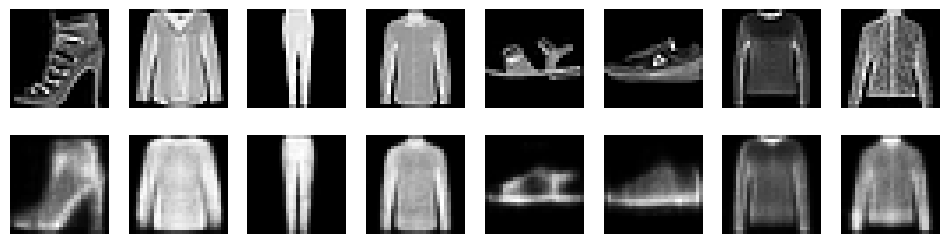

In [53]:
model.eval()

with torch.no_grad():
  x, _  = next(iter(train_loader))
  x = x.view(-1, 784).to(device)

  x_recon = model(x)

  n = 8
  plt.figure(figsize = (12, 3))

  for i in range(n):
      plt.subplot(2, n, i+1)
      plt.imshow(x[i].view(28, 28), cmap="gray")
      plt.axis("off")

      plt.subplot(2, n, i+1+n)
      plt.imshow(x_recon[i].view(28, 28), cmap="gray")
      plt.axis("off")

  plt.show()



### 3D Visualization of Latent Space
To visualize the high-dimensional latent space (32 dimensions in this case) in 3D, we'll use Principal Component Analysis (PCA) to reduce the dimensions to 3. Each point in the scatter plot will represent a digit from the test set, and its color will indicate the actual digit it represents.

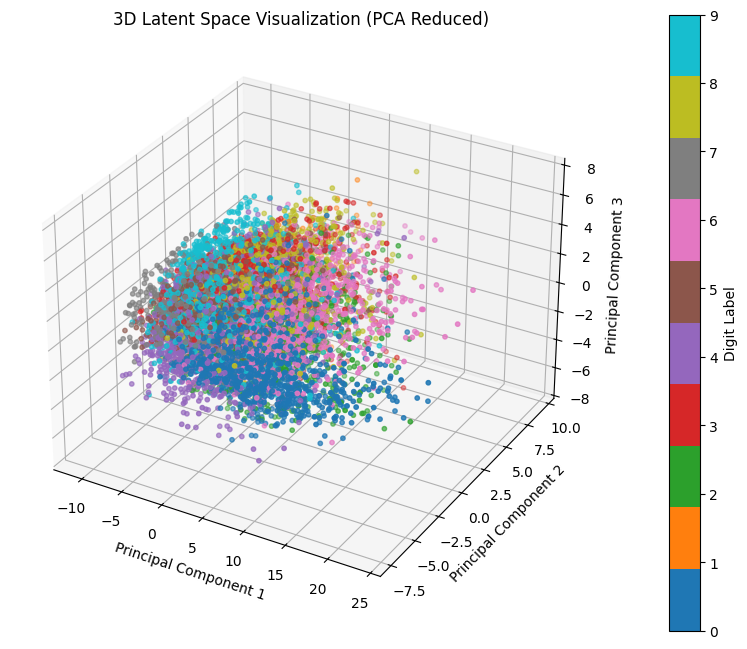

In [54]:
from sklearn.decomposition import PCA
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

model.eval()

latent_vectors = []
labels = []

with torch.no_grad():
  for x, y in test_loader:
    x = x.view(-1, 784).to(device)
    z = model.encoder(x)
    latent_vectors.append(z.cpu().numpy())
    labels.append(y.cpu().numpy())

latent_vectors = np.concatenate(latent_vectors, axis=0)
labels = np.concatenate(labels, axis=0)


pca = PCA(n_components=3)
latent_3d = pca.fit_transform(latent_vectors)


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(latent_3d[:, 0], latent_3d[:, 1], latent_3d[:, 2], c=labels, cmap='tab10', s=10)

ax.set_title('3D Latent Space Visualization (PCA Reduced)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Add a color bar to indicate digit labels
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Digit Label')

plt.show()

for random vector

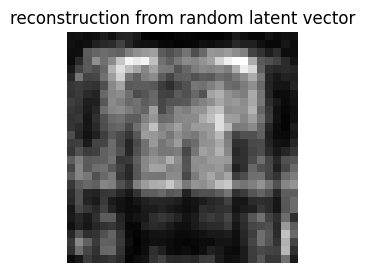

In [55]:
model.eval()

with torch.no_grad():
  latent_dim = model.encoder[-2].out_features
  x_random = torch.randn(1, latent_dim).to(device)

  x_generated = model.decoder(x_random)
  x_generated = x_generated.cpu().view(28, 28)

plt.figure(figsize=(3, 3))
plt.imshow(x_generated, cmap= "gray")
plt.axis("off")
plt.title("reconstruction from random latent vector")
plt.show()